# **Stroke Predictor App- Data Visualistion and EDA**

## Objectives

* Import dataset from clean data file
* Determine conclusions from visualisation of data
* Challenge Hypotheses via conclusions

## Inputs

* Dataset from the "Clean Data" CSV file, imported from Clean data folder

## Outputs

* Statistical Analysis of dataset
* Visualisations created from clean dataset
* Visualisations to compare against models built from Machine Learning
* Conclusions based off of data visualisation and exploratory data analysis




# Hypotheses

Due to the wide variety of variables and the possibility of  any one of these variables having an impact on stroke likelihood, it is important to derive and test hypotheses against all of these variables:

1) Age
    * As a patient's age increases, so will the likelhood of stroke occurrences.
2) Blood glucose
    * As a patient's blood glucose levels increase, so will the likelihood of stroke occurrences.
3) Heart Disease
    * If a patient has heart disease, then they are more likely to have a stroke.
4) Hypertension
    * If a patient has hypertension, then they are more likeyly to have a stroke.
5) Gender
    * Gender has no impact on stroke likelihood.
6) Smoking history
    * Smoking has a direct impact on stroke likelihood.
7) BMI
    * Higher BMI's indicate a higher likelihood of stroke occurrences.
8) Marital History
    * Marriage has no relation to stroke occurrence likelihood.
9) Job type
    * Job type has no relation to stroke occurrence likelihood.
10) Residence type
    * Residence type has no relation to stroke occurrence likelihood.


# Statistics

Write statistical descriptions here (mean, mode, median, t test, standard deviation, p-value)

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\naqas\\OneDrive\\Documents\\Coding\\CI_Projects\\stroke_prediction_app\\stroke_prediction_app\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\naqas\\OneDrive\\Documents\\Coding\\CI_Projects\\stroke_prediction_app\\stroke_prediction_app'

---

# Import required packages

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
import plotly.express as px
import plotly.io as pio
from scipy.stats import ttest_ind

---

# Import Clean Dataset

As the data has been cleaned, to visualise it, it is important to import the clean dataset as a new dataframe.

In [5]:
clean_stroke_data_df = pd.read_csv("data_files/CleanData/stroke_data_clean.csv")
clean_stroke_data_df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
3420,Male,82,1,0,Yes,Self-employed,Rural,71.97,28.3,never smoked,0
3421,Female,57,0,0,Yes,Private,Rural,77.93,21.7,never smoked,0
3422,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
3423,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0


---

## _Numerical Data_

The data is split as "Numerical" and "Categorical" data. We will visualise the Numerical data first and then the categorical data with statistical analysis included. The numerical data includes the following fields:

* Age
* Average Blood Glucose Level
* BMI

Additionally, as we are assessing stroke likelihood, the stroke feature will also be compared against even though in this dataset it is categorical.

The first visualisation will be a correlation matrix to see if there are any significant correlations between all the numerical pieces of data and strokes.

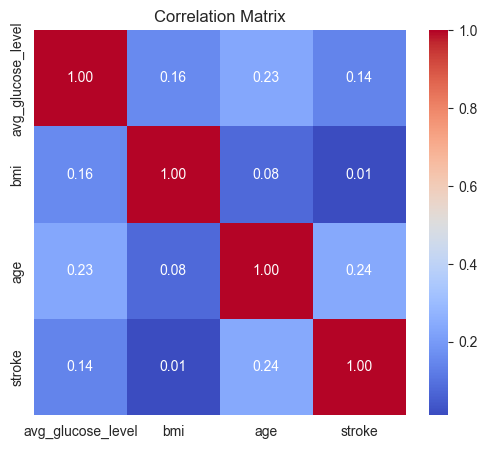

In [6]:
plt.figure(figsize=(6,5))
corr = clean_stroke_data_df[['avg_glucose_level', 'bmi', 'age'] + ['stroke']].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

C:\Users\naqas\AppData\Local\Temp\ipykernel_23432\1975640806.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


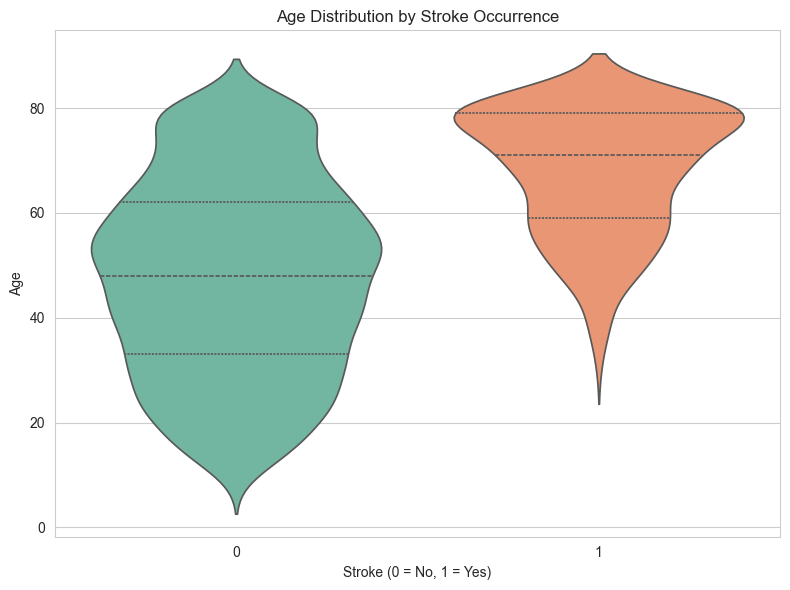

In [7]:
plt.figure(figsize=(8, 6))

sns.violinplot(
    data=clean_stroke_data_df,
    x="stroke",        # categorical (0 = no stroke, 1 = stroke)
    y="age",           # your numerical column
    palette="Set2",
    inner="quartile"   # shows median + quartiles inside
)

plt.title("Age Distribution by Stroke Occurrence")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

C:\Users\naqas\AppData\Local\Temp\ipykernel_23432\3284631743.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


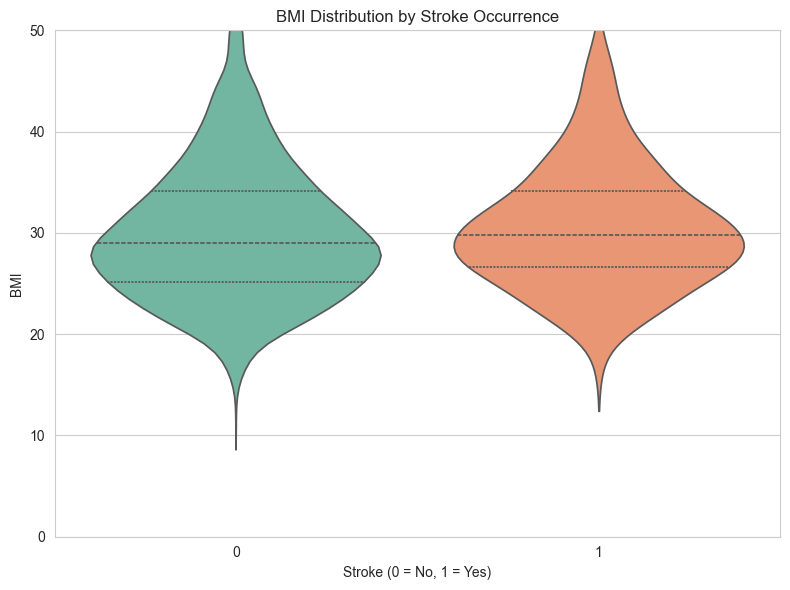

In [8]:
plt.figure(figsize=(8, 6))

sns.violinplot(
    data=clean_stroke_data_df,
    x="stroke",        # categorical (0 = no stroke, 1 = stroke)
    y="bmi",           # your numerical column
    palette="Set2",
    inner="quartile"   # shows median + quartiles inside
)

plt.title("BMI Distribution by Stroke Occurrence")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("BMI")
plt.ylim(0,50)
plt.tight_layout()
plt.show()

C:\Users\naqas\AppData\Local\Temp\ipykernel_23432\1930572415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_filtered, x="stroke", palette="Set2")


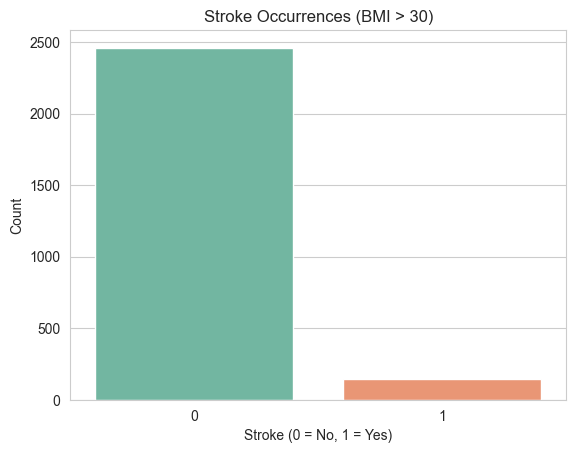

In [9]:
df_filtered = clean_stroke_data_df[clean_stroke_data_df["bmi"] > 25]

sns.countplot(data=df_filtered, x="stroke", palette="Set2")

plt.title("Stroke Occurrences (BMI > 30)")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

C:\Users\naqas\AppData\Local\Temp\ipykernel_23432\238765494.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


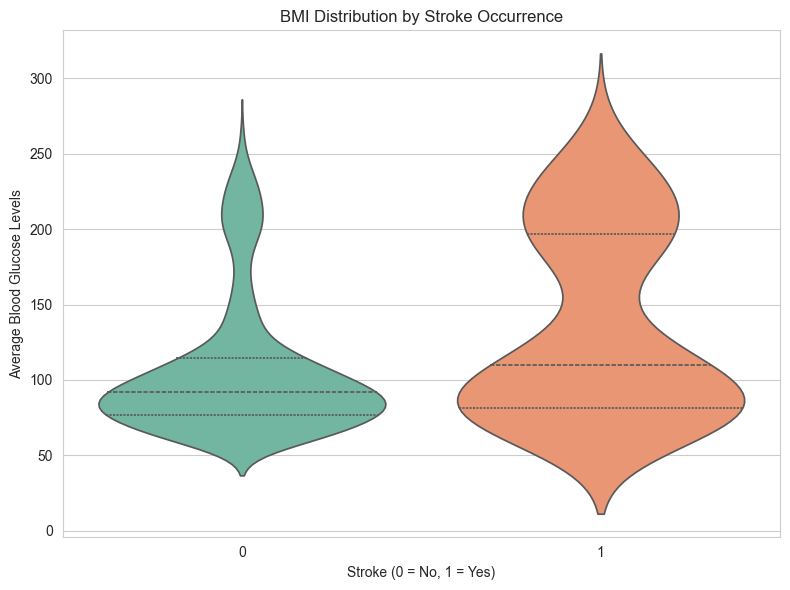

In [10]:
plt.figure(figsize=(8, 6))

sns.violinplot(
    data=clean_stroke_data_df,
    x="stroke",        # categorical (0 = no stroke, 1 = stroke)
    y="avg_glucose_level",           # your numerical column
    palette="Set2",
    inner="quartile"   # shows median + quartiles inside
)

plt.title("BMI Distribution by Stroke Occurrence")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Average Blood Glucose Levels")
plt.tight_layout()
plt.show()

C:\Users\naqas\AppData\Local\Temp\ipykernel_23432\2534871485.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  glucose_lower_section_bar = sns.countplot(data=lower_section_average_glucose_level_df, x="stroke", palette="Set2", stat= "percent")


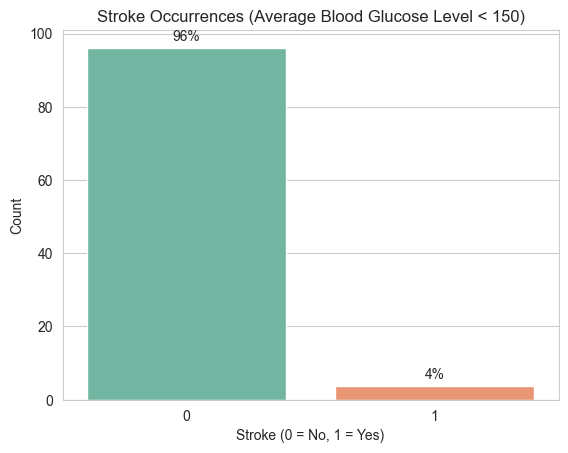

Variance= 14.32951461736275
Standard Deviation= 0.7063558106543905


In [11]:
lower_section_average_glucose_level_df = clean_stroke_data_df[clean_stroke_data_df["avg_glucose_level"] < 150]

glucose_lower_section_bar = sns.countplot(data=lower_section_average_glucose_level_df, x="stroke", palette="Set2", stat= "percent")

for container in glucose_lower_section_bar.containers:
    labels = [f'{v.get_height():.0f}%' for v in container]
    glucose_lower_section_bar.bar_label(container, labels=labels, padding= 3)

plt.title("Stroke Occurrences (Average Blood Glucose Level < 150)")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


total_rows_lower_section = lower_section_average_glucose_level_df.shape[0]
print(f"Variance= {((lower_section_average_glucose_level_df["avg_glucose_level"].var()) /total_rows_lower_section) * 100 }")
print(f"Standard Deviation= {((lower_section_average_glucose_level_df["avg_glucose_level"].std())/ total_rows_lower_section) * 100}")




C:\Users\naqas\AppData\Local\Temp\ipykernel_23432\1933311014.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  glucose_higher_section_bar = sns.countplot(data=higher_section_average_glucose_level_df, x="stroke", palette="Set2", stat= "percent")


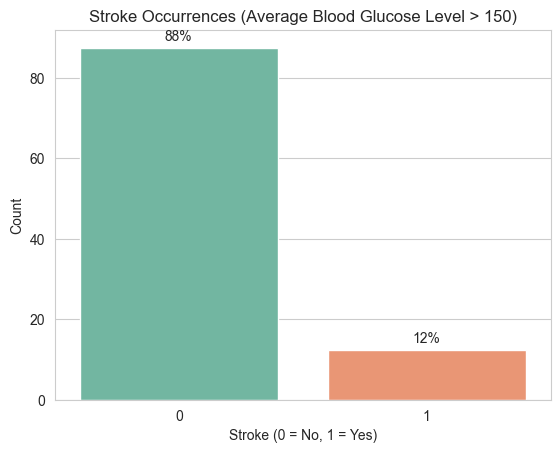

Variance= 128.2575795935855
Standard Deviation= 4.815916565695151


In [12]:
higher_section_average_glucose_level_df = clean_stroke_data_df[clean_stroke_data_df["avg_glucose_level"] > 150]

glucose_higher_section_bar = sns.countplot(data=higher_section_average_glucose_level_df, x="stroke", palette="Set2", stat= "percent")

for container in glucose_higher_section_bar.containers:
    labels = [f'{v.get_height():.0f}%' for v in container]
    glucose_higher_section_bar.bar_label(container, labels=labels, padding= 3)

plt.title("Stroke Occurrences (Average Blood Glucose Level > 150)")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


total_rows_higher_section = higher_section_average_glucose_level_df.shape[0]
print(f"Variance= {((higher_section_average_glucose_level_df["avg_glucose_level"].var()) /total_rows_higher_section) * 100 }")
print(f"Standard Deviation= {((higher_section_average_glucose_level_df["avg_glucose_level"].std())/ total_rows_higher_section) * 100}")

In [13]:
total_rows_stroke_df = clean_stroke_data_df.shape[0]
print(f"Variance= {((clean_stroke_data_df["avg_glucose_level"].var()) /total_rows_stroke_df) * 100 }")
print(f"Standard Deviation= {((clean_stroke_data_df["avg_glucose_level"].std())/ total_rows_stroke_df) * 100}")

Variance= 66.45063792931971
Standard Deviation= 1.3928979183971195


In [14]:
clean_stroke_data_df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000,3425.000000
mean,48.652555,0.119124,0.060146,108.311670,30.292350,0.052555
std,18.850018,0.323982,0.237792,47.706754,7.295778,0.223175
min,10.000000,0.000000,0.000000,55.120000,11.500000,0.000000
25%,34.000000,0.000000,0.000000,77.230000,25.300000,0.000000
50%,50.000000,0.000000,0.000000,92.350000,29.100000,0.000000
75%,63.000000,0.000000,0.000000,116.200000,34.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,92.000000,1.000000


In [15]:
t_stat, p_value = ttest_ind(higher_section_average_glucose_level_df[higher_section_average_glucose_level_df['stroke'] == 1]['avg_glucose_level'], lower_section_average_glucose_level_df[lower_section_average_glucose_level_df['stroke'] == 1]['avg_glucose_level'], equal_var=False)
print("T-statistic:", t_stat)
print("P-value=",p_value)

T-statistic: 32.883301361430185
P-value= 4.892227216166172e-62


T value shows a difference in the means, divided by the variance of the datasets. The t stat is showing statistical difference due to such a high value which means the difference in stroke count can not be accounted for by the noise in the dataset. 
The p-value is so small that the difference between stroke occurrences in the higher and lower glucose level regions is shown to be statistically significant and the noise can not be considered as a reason for this.



(EDIT THIS MARKDOWN)

## _Categorical Data_

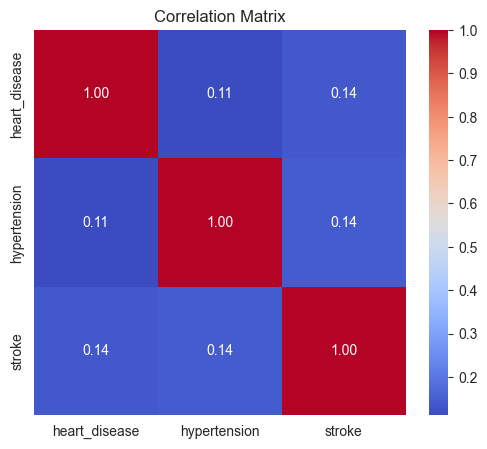

In [20]:
plt.figure(figsize=(6,5))
corr = clean_stroke_data_df[[ 'heart_disease', 'hypertension'] + ['stroke']].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

To visualise the data it will be necessary to create a summary of stroke occurrences against certain criteria. For example in the first graph where we will compare gender and stroke occurrences, it is essential to sum how many positive and negative stroke occurrences there are per male and female.

Once this summary has been created, it is possible to visualise this data in a bar chart.

In [16]:
stroke_summary = clean_stroke_data_df.groupby(["gender", "stroke"])["stroke"].count().reset_index(name="count")

<Figure size 1500x600 with 0 Axes>

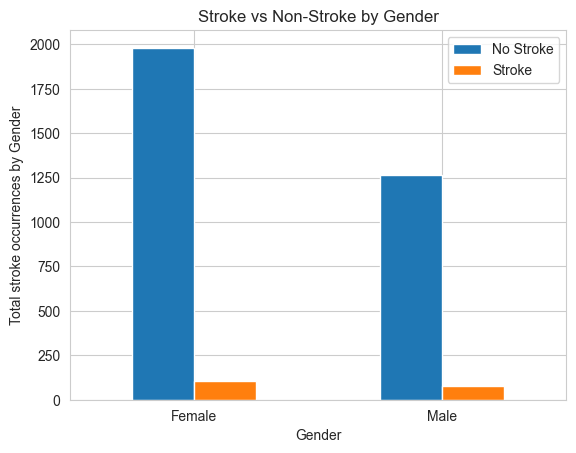

In [17]:
plt.figure(figsize=(15,6))
stroke_summary.pivot(index="gender", columns="stroke", values="count").plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Total stroke occurrences by Gender")
plt.title("Stroke vs Non-Stroke by Gender")
plt.xticks(rotation=0)
plt.legend(["No Stroke", "Stroke"])
plt.show()

From the above bar chart we can see that stroke occurrences are significantly higher in women than it is in men.

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [18]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)